In [2]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, norm

# Nice plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries loaded!")

✅ Libraries loaded!


In [3]:
#Load & Explore Data
# Load dataset
df = pd.read_csv('data/marketing_AB.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTest group distribution:")
print(df['test group'].value_counts())

Shape: (588101, 7)

First 5 rows:
   Unnamed: 0  user id test group  converted  total ads most ads day  \
0           0  1069124         ad      False        130       Monday   
1           1  1119715         ad      False         93      Tuesday   
2           2  1144181         ad      False         21      Tuesday   
3           3  1435133         ad      False        355      Tuesday   
4           4  1015700         ad      False        276       Friday   

   most ads hour  
0             20  
1             22  
2             18  
3             10  
4             14  

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-

  test group   Total  Converted  Conversion_Rate
0         ad  564577      14423             2.55
1        psa   23524        420             1.79


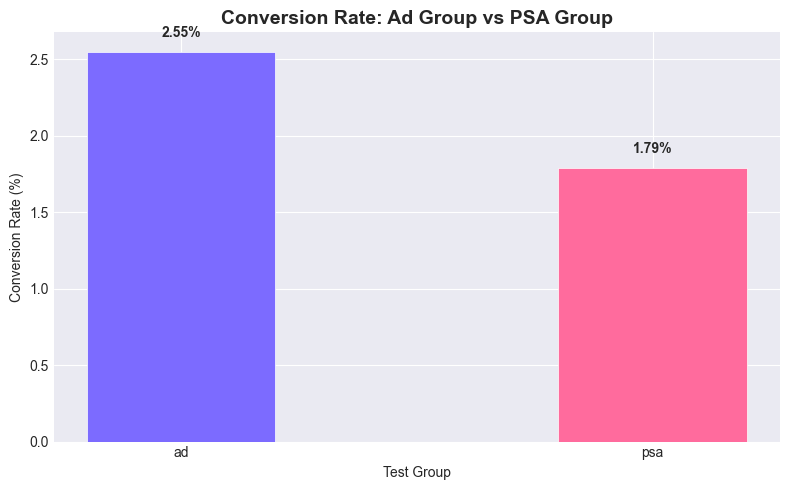

In [5]:
# Calculate conversion rates for each group
conversion = df.groupby('test group')['converted'].agg(
    Total='count',
    Converted='sum'
).reset_index()

conversion['Conversion_Rate'] = (
    conversion['Converted'] / conversion['Total'] * 100
).round(2)

print(conversion)

# ---- CHART 1: Bar chart of conversion rates ----
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#7c6bff', '#ff6b9d']
bars = ax.bar(
    conversion['test group'],
    conversion['Conversion_Rate'],
    color=colors, width=0.4, edgecolor='white', linewidth=0.5
)

# Add value labels on bars
for bar, rate in zip(bars, conversion['Conversion_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
           bar.get_height() + 0.1,
           f'{rate}%', ha='center', fontweight='bold')

ax.set_title('Conversion Rate: Ad Group vs PSA Group',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Test Group')
ax.set_ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.savefig('images/conversion_rate.png', dpi=150)
plt.show()


***Hypothesis Testing (Chi-Square)***

This is the core of the project. We test: "Is the difference in conversion rates statistically significant, or just random chance?"

In [7]:
# ============================================
# HYPOTHESIS TESTING — CHI-SQUARE TEST
# H0: No difference in conversion rates
# H1: There IS a significant difference
# Significance level: alpha = 0.05
# ============================================

# Build contingency table
contingency = pd.crosstab(
    df['test group'],
    df['converted']
)
print("Contingency Table:")
print(contingency)

# Run chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"\n Chi-Square Statistic : {chi2:.4f}")
print(f" P-Value              : {p_value:.6f}")
print(f" Degrees of Freedom   : {dof}")

alpha = 0.05
print(f"\n Alpha (significance) : {alpha}")

if p_value < alpha:
    print("\n RESULT: Reject H0 — Significant difference!")
    print("   The ad campaign DID have a real impact on conversions.")
else:
    print("\n RESULT: Fail to reject H0 — No significant difference.")
    print("   The difference may be due to random chance.")

Contingency Table:
converted    False  True 
test group               
ad          550154  14423
psa          23104    420

 Chi-Square Statistic : 54.0058
 P-Value              : 0.000000
 Degrees of Freedom   : 1

 Alpha (significance) : 0.05

 RESULT: Reject H0 — Significant difference!
   The ad campaign DID have a real impact on conversions.


***Ads Timing Analysis***

Bonus analysis: find which day and hour of the week gets the highest conversions.

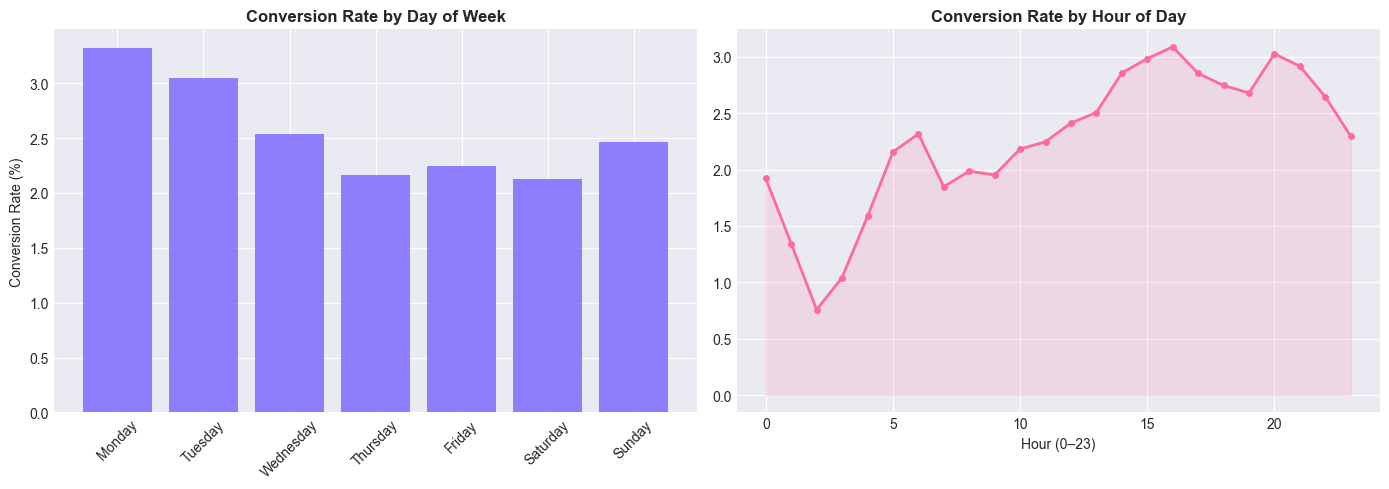

In [8]:
# Filter only the 'ad' group
ad_group = df[df['test group'] == 'ad']

# Conversion rate by day
day_conv = ad_group.groupby('most ads day')['converted'].mean() * 100
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
day_conv = day_conv.reindex(day_order)

# Conversion rate by hour
hour_conv = ad_group.groupby('most ads hour')['converted'].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Day chart
ax1.bar(day_conv.index, day_conv.values, color='#7c6bff', alpha=0.85)
ax1.set_title('Conversion Rate by Day of Week', fontweight='bold')
ax1.set_ylabel('Conversion Rate (%)')
ax1.tick_params(axis='x', rotation=45)

# Hour chart
ax2.plot(hour_conv.index, hour_conv.values,
        color='#ff6b9d', linewidth=2, marker='o', markersize=4)
ax2.fill_between(hour_conv.index, hour_conv.values, alpha=0.15, color='#ff6b9d')
ax2.set_title('Conversion Rate by Hour of Day', fontweight='bold')
ax2.set_xlabel('Hour (0–23)')

plt.tight_layout()
plt.savefig('images/timing_analysis.png', dpi=150)
plt.show()

***Business Insights Summary***

In [9]:
# ============================================================
# BUSINESS INSIGHTS SUMMARY
# ============================================================

ad_rate  = conversion[conversion['test group']=='ad']['Conversion_Rate'].values[0]
psa_rate = conversion[conversion['test group']=='psa']['Conversion_Rate'].values[0]
lift     = ((ad_rate - psa_rate) / psa_rate * 100).round(1)

best_day  = day_conv.idxmax()
best_hour = hour_conv.idxmax()

print("""
╔══════════════════════════════════════════════╗
║         BUSINESS INSIGHTS REPORT            ║
╠══════════════════════════════════════════════╣""")
print(f"║  Ad Group Conversion Rate : {ad_rate}%              ║")
print(f"║  PSA Group Conversion Rate: {psa_rate}%              ║")
print(f"║  Conversion Lift (Ad/PSA) : +{lift}%             ║")
print(f"║  Best Day to Run Ads      : {best_day}          ║")
print(f"║  Best Hour to Run Ads     : {best_hour}:00 hrs           ║")
print(f"║  Statistical Significance : YES (p < 0.05)  ║")
print("""╚══════════════════════════════════════════════╝

 RECOMMENDATION:
   Continue running the ad campaign. The ad group
   shows a statistically significant higher conversion
   rate. Focus ads on the best-performing day and hour
   for maximum ROI.
""")


╔══════════════════════════════════════════════╗
║         BUSINESS INSIGHTS REPORT            ║
╠══════════════════════════════════════════════╣
║  Ad Group Conversion Rate : 2.55%              ║
║  PSA Group Conversion Rate: 1.79%              ║
║  Conversion Lift (Ad/PSA) : +42.5%             ║
║  Best Day to Run Ads      : Monday          ║
║  Best Hour to Run Ads     : 16:00 hrs           ║
║  Statistical Significance : YES (p < 0.05)  ║
╚══════════════════════════════════════════════╝

 RECOMMENDATION:
   Continue running the ad campaign. The ad group
   shows a statistically significant higher conversion
   rate. Focus ads on the best-performing day and hour
   for maximum ROI.

